In [20]:
#random forest model
#a RF model does not need feature scaling
#robust to weird feature distributions
#handles non-linear patterns
#pipeline is simpler compared to LR

In [21]:
import pandas as pd
import os
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
os.listdir('/content/drive/MyDrive/AI4/Processed')

['tf0_processed.parquet', 'tf1_ByteEntropy.parquet', 'tf1_processed.parquet']

In [24]:
tf1 = pd.read_parquet('/content/drive/MyDrive/AI4/Processed/tf1_processed.parquet')
tf1.shape

(158158, 570)

In [25]:
#count real labels
tf1['label'].value_counts()

,count
label,
1,63713
0,52338
-1,42107


In [26]:
#remove unlabeled samples
tf1_clean = tf1[tf1['label'].isin([0,1])].copy()
tf1_clean['label'].value_counts()

,count
label,
1,63713
0,52338


In [27]:
#train/validation split
X = tf1_clean.drop(columns=['label'])
y = tf1_clean['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_val.shape

((92840, 569), (23211, 569))

In [28]:
#import RF
from sklearn.ensemble import RandomForestClassifier

In [29]:
#define what RF is
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [30]:
#train RF
rf_model.fit(X_train, y_train)

print("training complete.")

training complete.


In [31]:
#make predictions

In [32]:
#predicted class labels (0 or 1)
rf_preds = rf_model.predict(X_val)

#predicted probabilities for positive class (m=1)
rf_probs = rf_model.predict_proba(X_val)[:,1]

print ("random forest predictions complete.")

random forest predictions complete.


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

rf_accuracy = accuracy_score(y_val, rf_preds)
rf_precision = precision_score(y_val, rf_preds)
rf_recall = recall_score(y_val, rf_preds)
rf_f1 = f1_score(y_val, rf_preds)
rf_roc_auc = roc_auc_score(y_val, rf_probs)
rf_cm = confusion_matrix(y_val, rf_preds)

print("random forest results")
print("...")
print("accuracy:", rf_accuracy)
print("precision:", rf_precision)
print("recall:", rf_recall)
print("f1 score:", rf_f1)
print("ROC-AUC:", rf_roc_auc)
print("\nconfusion matrix:\n", rf_cm)


random forest results
...
accuracy: 0.908577829477403
precision: 0.9311520662498985
recall: 0.9000235423369694
f1 score: 0.9153232242617717
ROC-AUC: 0.9718345257382575

confusion matrix:
 [[ 9620   848]
 [ 1274 11469]]


In [34]:
rf_model

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

Random Forest Confusion Matrix:
[[ 9620   848]
 [ 1274 11469]]


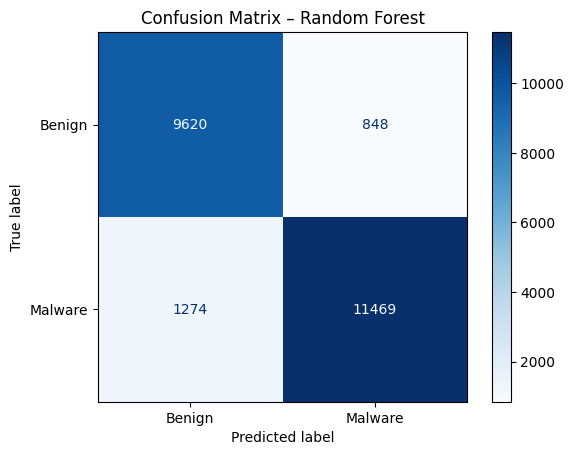

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#RF predictions
y_pred_rf = rf_model.predict(X_val)

#confusion matrix
cm_rf = confusion_matrix(y_val, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

#plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Benign", "Malware"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Random Forest")
plt.show()

**SEMESTER 2 - Threshold-Based Evaluation**

In [36]:
#obtain predicted probabiliyoes for MALWARE class (label = 1)
rf_probs = rf_model.predict_proba(X_val)[:, 1]

In [37]:
#apply a lower decision threshold to prioritise malware recall
#default = 0.5
#we test 0.3 to reduce FNs
threshold = 0.3
rf_pred_03 = (rf_probs >= threshold).astype(int)

In [38]:
#evaluate performance at new threshold
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

cm_03 = confusion_matrix(y_val, rf_pred_03)

acc_03 = accuracy_score(y_val, rf_pred_03)
prec_03 = precision_score(y_val, rf_pred_03, zero_division=0)
rec_03 = recall_score(y_val, rf_pred_03, zero_division=0)
f1_03 = f1_score(y_val, rf_pred_03, zero_division=0)

print("Threshold:", threshold)
print("Accuracy:", acc_03)
print("Precision:", prec_03)
print("Recall:", rec_03)
print("F1:", f1_03)
print("Confusion Matrix:\n", cm_03)

Threshold: 0.3
Accuracy: 0.8414975658093146
Precision: 0.7839954881564106
Recall: 0.981793926077062
F1: 0.8718163130204523
Confusion Matrix:
 [[ 7021  3447]
 [  232 12511]]


In [39]:
#threshold 0.4

threshold_04 = 0.4
rf_pred_04 = (rf_probs >= threshold_04).astype(int)

cm_04 = confusion_matrix(y_val, rf_pred_04)

acc_04 = accuracy_score(y_val, rf_pred_04)
prec_04 = precision_score(y_val, rf_pred_04, zero_division=0)
rec_04 = recall_score(y_val, rf_pred_04, zero_division=0)
f1_04 = f1_score(y_val, rf_pred_04, zero_division=0)

print("Threshold:", threshold_04)
print("Accuracy:", acc_04)
print("Precision:", prec_04)
print("Recall:", rec_04)
print("F1:", f1_04)
print("Confusion Matrix:\n", cm_04)

Threshold: 0.4
Accuracy: 0.8904398776442204
Precision: 0.862937660119556
Recall: 0.9515812602997724
F1: 0.9050942339988803
Confusion Matrix:
 [[ 8542  1926]
 [  617 12126]]


In [40]:
#threshold 0.45

threshold_045 = 0.45
rf_pred_045 = (rf_probs >= threshold_045).astype(int)

cm_045 = confusion_matrix(y_val, rf_pred_045)

acc_045 = accuracy_score(y_val, rf_pred_045)
prec_045 = precision_score(y_val, rf_pred_045, zero_division=0)
rec_045 = recall_score(y_val, rf_pred_045, zero_division=0)
f1_045 = f1_score(y_val, rf_pred_045, zero_division=0)

print("Threshold:", threshold_045)
print("Accuracy:", acc_045)
print("Precision:", prec_045)
print("Recall:", rec_045)
print("F1:", f1_045)
print("Confusion Matrix:\n", cm_045)

Threshold: 0.45
Accuracy: 0.9037094481065012
Precision: 0.8985133495145631
Recall: 0.9296084124617437
F1: 0.9137964284336791
Confusion Matrix:
 [[ 9130  1338]
 [  897 11846]]


In [41]:
#threshold comparison table

import pandas as pd

threshold_summary = pd.DataFrame([
    {
        "Threshold": 0.5,
        "Precision": 0.9311520662498985,
        "Recall": 0.9000235423369694,
        "F1": 0.9153232242617717,
        "FP": 848,
        "FN": 1274
    },
    {
        "Threshold": 0.45,
        "Precision": prec_045,
        "Recall": rec_045,
        "F1": f1_045,
        "FP": cm_045[0,1],
        "FN": cm_045[1,0]
    },
    {
        "Threshold": 0.4,
        "Precision": prec_04,
        "Recall": rec_04,
        "F1": f1_04,
        "FP": cm_04[0,1],
        "FN": cm_04[1,0]
    },
    {
        "Threshold": 0.3,
        "Precision": prec_03,
        "Recall": rec_03,
        "F1": f1_03,
        "FP": cm_03[0,1],
        "FN": cm_03[1,0]
    }
])

threshold_summary

,Threshold,Precision,Recall,F1,FP,FN
0,0.50,0.931152,0.900024,0.915323,848,1274
1,0.45,0.898513,0.929608,0.913796,1338,897
2,0.40,0.862938,0.951581,0.905094,1926,617
3,0.30,0.783995,0.981794,0.871816,3447,232


In [42]:
#cost-sensitive RF

#variant 1: balanced class weighting
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)

#predictions using default threshold (0.5)
rf_bal_pred = rf_balanced.predict(X_val)

#evaluate
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm_bal = confusion_matrix(y_val, rf_bal_pred)

acc_bal = accuracy_score(y_val, rf_bal_pred)
prec_bal = precision_score(y_val, rf_bal_pred, zero_division=0)
rec_bal = recall_score(y_val, rf_bal_pred, zero_division=0)
f1_bal = f1_score(y_val, rf_bal_pred, zero_division=0)

print("Balanced RF Results")
print("Accuracy:", acc_bal)
print("Precision:", prec_bal)
print("Recall:", rec_bal)
print("F1:", f1_bal)
print("Confusion Matrix:\n", cm_bal)

Balanced RF Results
Accuracy: 0.9092671578131059
Precision: 0.9301253538212697
Recall: 0.9025347249470297
F1: 0.9161223514417716
Confusion Matrix:
 [[ 9604   864]
 [ 1242 11501]]


In [43]:
#custom weight RF (malware x3)

rf_weighted = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight={0:1, 1:3}
)

rf_weighted.fit(X_train, y_train)

rf_weighted_pred = rf_weighted.predict(X_val)

cm_w = confusion_matrix(y_val, rf_weighted_pred)

acc_w = accuracy_score(y_val, rf_weighted_pred)
prec_w = precision_score(y_val, rf_weighted_pred, zero_division=0)
rec_w = recall_score(y_val, rf_weighted_pred, zero_division=0)
f1_w = f1_score(y_val, rf_weighted_pred, zero_division=0)

print("Custom Weighted RF Results (1:3)")
print("Accuracy:", acc_w)
print("Precision:", prec_w)
print("Recall:", rec_w)
print("F1:", f1_w)
print("Confusion Matrix:\n", cm_w)

Custom Weighted RF Results (1:3)
Accuracy: 0.9084054973934772
Precision: 0.9432245136511648
Recall: 0.8865259358078945
F1: 0.9139967637540453
Confusion Matrix:
 [[ 9788   680]
 [ 1446 11297]]


In [44]:
#custom weight RF (malware x2)

rf_weighted_2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight={0:1, 1:2}
)

rf_weighted_2.fit(X_train, y_train)

rf_weighted_2_pred = rf_weighted_2.predict(X_val)

cm_w2 = confusion_matrix(y_val, rf_weighted_2_pred)

acc_w2 = accuracy_score(y_val, rf_weighted_2_pred)
prec_w2 = precision_score(y_val, rf_weighted_2_pred, zero_division=0)
rec_w2 = recall_score(y_val, rf_weighted_2_pred, zero_division=0)
f1_w2 = f1_score(y_val, rf_weighted_2_pred, zero_division=0)

print("Custom Weighted RF Results (1:2)")
print("Accuracy:", acc_w2)
print("Precision:", prec_w2)
print("Recall:", rec_w2)
print("F1:", f1_w2)
print("Confusion Matrix:\n", cm_w2)

Custom Weighted RF Results (1:2)
Accuracy: 0.9103442333376416
Precision: 0.9434370321078024
Recall: 0.890057286353292
F1: 0.9159701191197254
Confusion Matrix:
 [[ 9788   680]
 [ 1401 11342]]


In [45]:
#weighted (1:2) + threshold 0.45

rf_weighted_2_probs = rf_weighted_2.predict_proba(X_val)[:, 1]

threshold_combo = 0.45
rf_weighted_2_pred_045 = (rf_weighted_2_probs >= threshold_combo).astype(int)

cm_combo = confusion_matrix(y_val, rf_weighted_2_pred_045)

acc_combo = accuracy_score(y_val, rf_weighted_2_pred_045)
prec_combo = precision_score(y_val, rf_weighted_2_pred_045, zero_division=0)
rec_combo = recall_score(y_val, rf_weighted_2_pred_045, zero_division=0)
f1_combo = f1_score(y_val, rf_weighted_2_pred_045, zero_division=0)

print("Weighted (1:2) + Threshold 0.45")
print("Accuracy:", acc_combo)
print("Precision:", prec_combo)
print("Recall:", rec_combo)
print("F1:", f1_combo)
print("Confusion Matrix:\n", cm_combo)

Weighted (1:2) + Threshold 0.45
Accuracy: 0.9104303993796045
Precision: 0.9147479775980087
Recall: 0.9228596091972063
F1: 0.918785890073831
Confusion Matrix:
 [[ 9372  1096]
 [  983 11760]]


In [46]:
#final model comparison table

import pandas as pd

comparison_table = pd.DataFrame([
    {
        "Model": "Baseline (0.5)",
        "Precision": 0.9311520662498985,
        "Recall": 0.9000235423369694,
        "F1": 0.9153232242617717,
        "FP": 848,
        "FN": 1274
    },
    {
        "Model": "Threshold 0.45",
        "Precision": prec_045,
        "Recall": rec_045,
        "F1": f1_045,
        "FP": cm_045[0,1],
        "FN": cm_045[1,0]
    },
    {
        "Model": "Weighted (1:2)",
        "Precision": prec_w2,
        "Recall": rec_w2,
        "F1": f1_w2,
        "FP": cm_w2[0,1],
        "FN": cm_w2[1,0]
    },
    {
        "Model": "Weighted (1:2) + Threshold 0.45",
        "Precision": prec_combo,
        "Recall": rec_combo,
        "F1": f1_combo,
        "FP": cm_combo[0,1],
        "FN": cm_combo[1,0]
    }
])

comparison_table

,Model,Precision,Recall,F1,FP,FN
0,Baseline (0.5),0.931152,0.900024,0.915323,848,1274
1,Threshold 0.45,0.898513,0.929608,0.913796,1338,897
2,Weighted (1:2),0.943437,0.890057,0.915970,680,1401
3,Weighted (1:2) + Threshold 0.45,0.914748,0.922860,0.918786,1096,983


In [47]:
#light hyperparameter tuning

#we tune only parameters that directly control model complexity
# - max_depth & min_samples_leaf

from itertools import product
import pandas as pd

#candidate values (search space)
depth_options = [30, 20]      #skip None for speed
leaf_options  = [1, 5]        #keep it small

tuning_results = []

for depth, leaf in product(depth_options, leaf_options):

  #ce=reate tuned RF with moderate class weighting

    rf_tuned = RandomForestClassifier(
        n_estimators=80,         #scout (not final)
        random_state=42,
        n_jobs=-1,
        class_weight={0:1, 1:2}, #best weighting
        max_depth=depth,
        min_samples_leaf=leaf
    )

    #train model
    rf_tuned.fit(X_train, y_train)

    #get predicted probabilities
    probs = rf_tuned.predict_proba(X_val)[:, 1]
    #apply decision threshold
    preds = (probs >= 0.45).astype(int)

    #evaluate performance
    prec = precision_score(y_val, preds, zero_division=0)
    rec  = recall_score(y_val, preds, zero_division=0)
    f1   = f1_score(y_val, preds, zero_division=0)
    cm   = confusion_matrix(y_val, preds)

    #store results for comparison
    tuning_results.append({
        "max_depth": depth,
        "min_samples_leaf": leaf,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "FP": cm[0,1],
        "FN": cm[1,0]
    })

#convert results to DataFrame and sort by F1
tuning_df = pd.DataFrame(tuning_results).sort_values("F1", ascending=False)
tuning_df

,max_depth,min_samples_leaf,Precision,Recall,F1,FP,FN
0,30,1,0.904556,0.920741,0.912577,1238,1010
2,20,1,0.859143,0.948678,0.901693,1982,654
1,30,5,0.854102,0.954171,0.901368,2077,584
3,20,5,0.835560,0.961783,0.894240,2412,487


In [48]:
#final tuned model

rf_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight={0:1, 1:2},
    max_depth=30,
    min_samples_leaf=1
)

rf_final.fit(X_train, y_train)

final_probs = rf_final.predict_proba(X_val)[:, 1]
final_preds = (final_probs >= 0.45).astype(int)

cm_final = confusion_matrix(y_val, final_preds)

print("FINAL Tuned (1:2, depth=30, leaf=1) + threshold 0.45")
print("Precision:", precision_score(y_val, final_preds, zero_division=0))
print("Recall:", recall_score(y_val, final_preds, zero_division=0))
print("F1:", f1_score(y_val, final_preds, zero_division=0))
print("Confusion Matrix:\n", cm_final)

FINAL Tuned (1:2, depth=30, leaf=1) + threshold 0.45
Precision: 0.9072760906428241
Recall: 0.9237228282194145
F1: 0.9154255939650815
Confusion Matrix:
 [[ 9265  1203]
 [  972 11771]]


In [49]:
#gini feature importance

#1) train the selected RF model configuration (weighted 1:2)
#note: threshold does NOT affect training, only final decision.
rf_selected = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight={0:1, 1:2}
)

rf_selected.fit(X_train, y_train)

print("rf_selected training complete.")


# 2)extract gini importances
#this measures how much each feature reduced impurity across splits, averaged over all trees.
gini_importances = rf_selected.feature_importances_


# 3)build a ranked table
gini_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Gini_Importance": gini_importances
}).sort_values("Gini_Importance", ascending=False)

#show top 20
gini_df.head(20)

rf_selected training complete.


,Feature,Gini_Importance
564,str.entropy,0.038295
4,gen.imports,0.037342
10,hdr.coff.timestamp,0.036329
561,str.avlength,0.035901
24,hdr.optional.sizeof_code,0.034485
568,str.MZ,0.032943
0,gen.size,0.032762
1,gen.vsize,0.032453
18,hdr.optional.major_linker_version,0.030655
563,str.printables,0.030304


In [50]:
#select top 30 features from gini ranking
top_features = gini_df["Feature"].head(30).tolist()

print("Number of features selected:", len(top_features))

Number of features selected: 30


In [51]:
import os, shutil
shutil.rmtree('/tmp', ignore_errors=True)
os.makedirs('/tmp', exist_ok=True)
print("Cleared /tmp")

Cleared /tmp


In [52]:
#permutation importance - top 30 model

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

#subset training + validation to top 30 gini features
X_train_top = X_train[top_features]
X_val_top = X_val[top_features]

#train a RF on top-30 only
rf_top30 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight={0:1, 1:2}
)
rf_top30.fit(X_train_top, y_train)

print("rf_top30 trained on Top-30 features.")

#sse a small validation subset for speed
SUBSET_N = 5000
rng = np.random.RandomState(42)

if len(X_val_top) > SUBSET_N:
    idx = rng.choice(len(X_val_top), size=SUBSET_N, replace=False)
    X_val_sub_top = X_val_top.iloc[idx]
    y_val_sub = y_val.iloc[idx]
else:
    X_val_sub_top = X_val_top
    y_val_sub = y_val

#permutation importance (no multiprocessing to avoid disk pickling issues)
perm_importance = permutation_importance(
    rf_top30,
    X_val_sub_top,
    y_val_sub,
    n_repeats=1,
    scoring="f1",
    random_state=42,
    n_jobs=1
)

#sort by permutation importance (high to low)
perm_df = pd.DataFrame({
    "Feature": top_features,
    "Permutation_Importance": perm_importance.importances_mean
}).sort_values("Permutation_Importance", ascending=False)

perm_df.head(20)

rf_top30 trained on Top-30 features.


,Feature,Permutation_Importance
5,str.MZ,0.046767
7,gen.vsize,0.041227
2,hdr.coff.timestamp,0.039086
18,gen.has_tls,0.030376
6,gen.size,0.028895
21,hdr.optional.major_image_version,0.025423
11,hdr.optional.minor_linker_version,0.020038
13,gen.has_debug,0.018760
1,gen.imports,0.018622
4,hdr.optional.sizeof_code,0.015535


In [53]:
#feature reduction setup

#feature subsets based on gini ranking
features_all = X_train.columns.tolist()
features_200 = gini_df["Feature"].head(200).tolist()
features_100 = gini_df["Feature"].head(100).tolist()
features_50  = gini_df["Feature"].head(50).tolist()

print("Feature sets prepared:")
print("All:", len(features_all))
print("Top 200:", len(features_200))
print("Top 100:", len(features_100))
print("Top 50:", len(features_50))

Feature sets prepared:
All: 569
Top 200: 200
Top 100: 100
Top 50: 50


In [54]:
#experiment for feature reduction

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

THRESHOLD = 0.45
SCOUT_TREES = 60   #fast scout

feature_sets = {
    "Top 200": features_200,
    "Top 100": features_100,
    "Top 50": features_50
}

reduction_results = []

for name, feats in feature_sets.items():
    print(f"\n--- Scout: {name} ({len(feats)} features) ---")

    X_train_sub = X_train[feats]
    X_val_sub = X_val[feats]

    rf = RandomForestClassifier(
        n_estimators=SCOUT_TREES,
        random_state=42,
        n_jobs=-1,
        class_weight={0:1, 1:2}
    )
    rf.fit(X_train_sub, y_train)

    probs = rf.predict_proba(X_val_sub)[:, 1]
    preds = (probs >= THRESHOLD).astype(int)

    prec = precision_score(y_val, preds, zero_division=0)
    rec  = recall_score(y_val, preds, zero_division=0)
    f1   = f1_score(y_val, preds, zero_division=0)
    cm   = confusion_matrix(y_val, preds)

    reduction_results.append({
        "Feature_Set": name,
        "Num_Features": len(feats),
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "FP": cm[0,1],
        "FN": cm[1,0]
    })

reduction_df_scout = pd.DataFrame(reduction_results).sort_values("Num_Features", ascending=False)
reduction_df_scout


--- Scout: Top 200 (200 features) ---

--- Scout: Top 100 (100 features) ---

--- Scout: Top 50 (50 features) ---


,Feature_Set,Num_Features,Precision,Recall,F1,FP,FN
0,Top 200,200,0.930531,0.934474,0.932498,889,835
1,Top 100,100,0.943864,0.942086,0.942974,714,738
2,Top 50,50,0.953708,0.950640,0.952171,588,629


In [55]:
#final confirmation (top 50 - full strength)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

THRESHOLD = 0.45

X_train_50 = X_train[features_50]
X_val_50 = X_val[features_50]

rf_final_50 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight={0:1, 1:2}
)

rf_final_50.fit(X_train_50, y_train)

probs = rf_final_50.predict_proba(X_val_50)[:, 1]
preds = (probs >= THRESHOLD).astype(int)

prec = precision_score(y_val, preds, zero_division=0)
rec  = recall_score(y_val, preds, zero_division=0)
f1   = f1_score(y_val, preds, zero_division=0)
cm   = confusion_matrix(y_val, preds)

print("FINAL Top 50 Model (200 trees)")
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("Confusion Matrix:\n", cm)

FINAL Top 50 Model (200 trees)
Precision: 0.957822267943341
Recall: 0.9498548222553559
F1: 0.9538219070133964
Confusion Matrix:
 [[ 9935   533]
 [  639 12104]]


In [56]:
#final model comparison table

import pandas as pd

final_models_df = pd.DataFrame([
    {
        "Model": "Baseline RF (All Features, 0.5)",
        "Num_Features": len(features_all),
        "Precision": 0.9311520662498985,
        "Recall": 0.9000235423369694,
        "F1": 0.9153232242617717,
        "False Positives": 848,
        "False Negatives": 1274
    },
    {
        "Model": "Weighted RF (1:2) + 0.45 (All Features)",
        "Num_Features": len(features_all),
        "Precision": 0.9147479775980087,
        "Recall": 0.9228596091972063,
        "F1": 0.918785890073831,
        "False Positives": 1096,
        "False Negatives": 983
    },
    {
        "Model": "Final RF (Top 50 Features, 0.45)",
        "Num_Features": 50,
        "Precision": 0.957822267943341,
        "Recall": 0.9498548222553559,
        "F1": 0.9538219070133964,
        "False Positives": 533,
        "False Negatives": 639
    }
])

final_models_df

,Model,Num_Features,Precision,Recall,F1,False Positives,False Negatives
0,"Baseline RF (All Features, 0.5)",569,0.931152,0.900024,0.915323,848,1274
1,Weighted RF (1:2) + 0.45 (All Features),569,0.914748,0.922860,0.918786,1096,983
2,"Final RF (Top 50 Features, 0.45)",50,0.957822,0.949855,0.953822,533,639


In [57]:
features_50

['str.entropy',
 'gen.imports',
 'hdr.coff.timestamp',
 'str.avlength',
 'hdr.optional.sizeof_code',
 'str.MZ',
 'gen.size',
 'gen.vsize',
 'hdr.optional.major_linker_version',
 'str.printables',
 'str.numstrings',
 'hdr.optional.minor_linker_version',
 'str.urls',
 'gen.has_debug',
 'gen.has_signature',
 'hdr.optional.major_subsystem_version',
 'hdr.optional.major_operating_system_version',
 'str.paths',
 'gen.has_tls',
 'sect.num_sections',
 'gen.exports',
 'hdr.optional.major_image_version',
 'exports.count',
 'hdr.optional.sizeof_headers',
 'hdr.optional.minor_subsystem_version',
 'gen.has_relocations',
 'hdr.optional.minor_operating_system_version',
 'str.registry',
 'gen.has_resources',
 'hdr.optional.sizeof_heap_commit',
 'hdr.optional.minor_image_version',
 'byte.231',
 'byte.229',
 'byte.227',
 'byte.228',
 'byte.230',
 'byte.226',
 'byte.147',
 'byte.146',
 'byte.148',
 'byte.233',
 'byte.145',
 'byte.240',
 'byte.150',
 'byte.224',
 'byte.232',
 'byte.239',
 'byte.234',
 'by

saving of files

In [58]:
#save features list
import json

with open("top50_features.json", "w") as f:
    json.dump(features_50, f)

print("Top-50 feature list saved.")

Top-50 feature list saved.


In [59]:
import os
os.listdir()

['.config', 'top50_features.json', 'drive', 'sample_data']

In [60]:
#save to correct place
import shutil

shutil.move(
    "top50_features.json",
    "/content/drive/MyDrive/AI4/Models/RF/top50_features.json"
)

print("Feature list moved to Google Drive.")

Feature list moved to Google Drive.


In [61]:
#save final model
import joblib

joblib.dump(rf_final_50, "rf_final_top50.joblib")

print("Final RF model saved.")

Final RF model saved.


In [62]:
import joblib

joblib.dump(
    rf_final_50,
    "/content/drive/MyDrive/AI4/Models/RF/rf_final_top50.joblib"
)

print("Final RF model saved to RF folder.")

Final RF model saved to RF folder.


In [63]:
#check
import os

os.listdir("/content/drive/MyDrive/AI4/Models/RF")

['RF_Development.ipynb',
 'Copy of Model_RF.ipynb',
 'External_Validation_EMBER_RF.ipynb',
 'top50_features.json',
 'rf_final_top50.joblib']